# Análisis Exploratorio de Datos

Autores:
* Belén Huertas Ruiz
* Carlos Naranjo Calderón
* Lucía Sánchez-Chiquito Gómez
* Daniel Sánchez Castro

# Constantes y configuración

In [1]:
import pandas as pd
import os

import matplotlib.pyplot as plt


DATA_DIR = "data"

# `cohorte_alergias.csv`

In [15]:
df_alergias_raw = pd.read_csv(os.path.join(DATA_DIR, "cohorte_alergias.csv"))
df_alergias = df_alergias_raw.copy()

In [45]:
df_alergias_raw

,PacienteID,Fecha_diagnostico,Codigo_SNOMED,Descripcion
0,22,2016-08-18,91936005,Alergia al polen
1,11,2023-02-15,91933007,Alergia a los frutos secos
2,27,2019-04-06,300913006,Alergia a la penicilina
3,15,2023-04-24,91931005,Alergia a la leche
4,25,2017-11-14,91931005,Alergia a la leche
...,...,...,...,...
95,12,2016-09-03,300913006,Alergia a la penicilina
96,2,2018-04-12,300914000,Alergia a la aspirina
97,20,2020-11-03,91935009,Alergia al pelo de gato
98,30,2021-05-27,91935009,Alergia al pelo de gato


In [44]:
conteo_alergias = df_alergias[['Codigo_SNOMED', 'Descripcion']].value_counts().reset_index(name='count')
conteo_alergias

,Codigo_SNOMED,Descripcion,count
0,91930004,Alergia a los ácaros del polvo,13
1,300914000,Alergia a la aspirina,12
2,91931005,Alergia a la leche,11
3,91936005,Alergia al polen,11
4,300913006,Alergia a la penicilina,11
5,91934008,Alergia a la picadura de abeja,10
6,91932006,Alergia a los mariscos,9
7,91933007,Alergia a los frutos secos,8
8,414285001,Alergia al látex,8
9,91935009,Alergia al pelo de gato,7


# `cohorte_condiciones.csv`

In [56]:
df_condiciones_raw = pd.read_csv(os.path.join(DATA_DIR, "cohorte_condiciones.csv"))
df_condiciones = df_condiciones_raw.copy()

In [57]:
df_condiciones_raw

,PacienteID,Fecha_inicio,Fecha_fin,Codigo_SNOMED,Descripcion
0,11,2023-11-21 10:18:27.267949,2025-03-10 10:18:27.267949,C0038356,Asma
1,10,2023-12-03 10:18:27.267949,2025-03-10 10:18:27.267949,C0020538,Diabetes tipo 2
2,20,2023-03-16 00:00:00.000000,2023-04-16 00:00:00.000000,C0027651,Migraña
3,17,2023-06-20 00:00:00.000000,2023-06-27 00:00:00.000000,C0027651,Migraña
4,8,2023-03-26 00:00:00.000000,2024-03-01 00:00:00.000000,C0009450,Neumonía
...,...,...,...,...,...
95,28,2023-09-24 00:00:00.000000,2024-09-02 00:00:00.000000,C0027651,Migraña
96,29,2023-10-13 10:18:27.267949,2025-03-10 10:18:27.267949,C0038356,Asma
97,13,2024-11-01 00:00:00.000000,2024-12-11 00:00:00.000000,C0042109,Fractura de brazo
98,27,2024-12-28 00:00:00.000000,2025-01-31 00:00:00.000000,C0042109,Fractura de brazo


In [58]:
conteo_condiciones = df_condiciones[['Codigo_SNOMED', 'Descripcion']].value_counts().reset_index(name='count')
conteo_condiciones

,Codigo_SNOMED,Descripcion,count
0,C0027651,Migraña,16
1,C0011849,Hipertensión,15
2,C0020538,Diabetes tipo 2,14
3,C0009450,Neumonía,14
4,C0038356,Asma,13
5,C0032285,Bronquitis,11
6,C0042109,Fractura de brazo,10
7,C0024117,Gripe,7


In [59]:
df_condiciones["duracion"] = pd.to_datetime(df_condiciones["Fecha_fin"]) - pd.to_datetime(df_condiciones["Fecha_inicio"])

In [60]:
df_condiciones["duracion"].describe()

count                            100
mean               286 days 22:04:48
std      247 days 12:59:22.211287024
min                  3 days 00:00:00
25%                 24 days 12:00:00
50%                342 days 12:00:00
75%                491 days 06:00:00
max                718 days 00:00:00
Name: duracion, dtype: object

In [61]:
stats_duracion_condicion = df_condiciones.groupby(['Codigo_SNOMED', 'Descripcion'])['duracion'].describe()
stats_duracion_condicion

,,count,mean,std,min,25%,50%,75%,max
Codigo_SNOMED,Descripcion,,,,,,,,
C0009450,Neumonía,14,121 days 05:08:34.285714286,150 days 09:02:57.428839730,4 days 00:00:00,9 days 18:00:00,31 days 00:00:00,280 days 00:00:00,360 days 00:00:00
C0011849,Hipertensión,15,555 days 14:24:00,108 days 01:12:10.423739802,412 days 00:00:00,464 days 00:00:00,546 days 00:00:00,653 days 00:00:00,712 days 00:00:00
C0020538,Diabetes tipo 2,14,559 days 08:34:17.142857144,106 days 16:58:11.783566638,410 days 00:00:00,466 days 00:00:00,542 days 12:00:00,659 days 12:00:00,718 days 00:00:00
C0024117,Gripe,7,11 days 00:00:00,11 days 08:56:22.393491762,3 days 00:00:00,3 days 12:00:00,6 days 00:00:00,16 days 00:00:00,29 days 00:00:00
C0027651,Migraña,16,122 days 04:30:00,145 days 23:42:23.380404736,3 days 00:00:00,6 days 12:00:00,29 days 00:00:00,205 days 18:00:00,359 days 00:00:00
C0032285,Bronquitis,11,143 days 13:05:27.272727272,158 days 16:31:35.300610460,20 days 00:00:00,26 days 00:00:00,36 days 00:00:00,323 days 12:00:00,362 days 00:00:00
C0038356,Asma,13,496 days 18:27:41.538461536,68 days 08:42:59.549047890,384 days 00:00:00,460 days 00:00:00,489 days 00:00:00,557 days 00:00:00,603 days 00:00:00
C0042109,Fractura de brazo,10,76 days 02:24:00,113 days 13:26:25.589291876,4 days 00:00:00,8 days 00:00:00,29 days 12:00:00,68 days 12:00:00,349 days 00:00:00


# `cohorte_encuentros.csv`

In [49]:
df_encuentros_raw = pd.read_csv(os.path.join(DATA_DIR, "cohorte_encuentros.csv"))
df_encuentros = df_encuentros_raw.copy()

In [50]:
df_encuentros_raw

,PacienteID,Tipo_encuentro,Fecha_inicio,Fecha_fin
0,1,Hospitalización,2024-11-11,2024-12-05
1,1,Hospitalización,2023-06-23,2023-07-10
2,1,Urgencia,2024-02-10,2024-02-16
3,2,Hospitalización,2024-01-17,2024-02-06
4,2,Atención Primaria,2023-06-13,2023-06-23
...,...,...,...,...
107,29,Atención Primaria,2025-03-03,2025-03-09
108,30,Urgencia,2024-05-07,2024-05-09
109,30,Atención Primaria,2024-01-07,2024-01-17
110,30,Hospitalización,2025-02-02,2025-03-04


In [52]:
df_encuentros["Tipo_encuentro"].value_counts()

Tipo_encuentro
Urgencia             42
Hospitalización      36
Atención Primaria    34
Name: count, dtype: int64

In [53]:
df_encuentros["duracion"] = pd.to_datetime(df_encuentros["Fecha_fin"]) - pd.to_datetime(df_encuentros["Fecha_inicio"])

In [54]:
df_encuentros["duracion"].describe()

count                          112
mean     9 days 04:04:17.142857142
std      8 days 01:52:46.828210233
min                1 days 00:00:00
25%                3 days 00:00:00
50%                7 days 00:00:00
75%               10 days 00:00:00
max               30 days 00:00:00
Name: duracion, dtype: object

In [62]:
stats_duracion_encuentros = df_encuentros.groupby(['Tipo_encuentro'])['duracion'].describe()
stats_duracion_encuentros

,count,mean,std,min,25%,50%,75%,max
Tipo_encuentro,,,,,,,,
Atención Primaria,34,5 days 09:52:56.470588235,3 days 05:30:51.570186461,1 days 00:00:00,2 days 00:00:00,5 days 12:00:00,8 days 00:00:00,10 days 00:00:00
Hospitalización,36,17 days 08:40:00,9 days 03:49:31.386897454,4 days 00:00:00,8 days 18:00:00,17 days 00:00:00,27 days 00:00:00,30 days 00:00:00
Urgencia,42,5 days 04:34:17.142857142,3 days 03:11:42.278313871,1 days 00:00:00,2 days 00:00:00,5 days 12:00:00,8 days 00:00:00,10 days 00:00:00


# `cohorte_medicationes.csv`

In [63]:
df_medicationes_raw = pd.read_csv(os.path.join(DATA_DIR, "cohorte_medicationes.csv"))
df_medicationes = df_medicationes_raw.copy()

In [64]:
df_medicationes_raw

,PacienteID,Fecha de inicio,Fecha de fin,Código,Nombre,Dosis,Frecuencia,Vía de administración
0,1,2018-06-01,NaN,C09AA03,Lisinopril,10 mg,1 vez al día,oral
1,1,2019-01-15,NaN,C03AA03,Hidroclorotiazida,25 mg,1 vez al día,oral
2,1,2018-06-05,NaN,C10AA05,Atorvastatina,20 mg,1 vez al día,oral
3,1,2018-06-01,NaN,B01AC06,Ácido acetilsalicílico,100 mg,1 vez al día,oral
4,2,2017-04-01,NaN,A10BA02,Metformina,500 mg,2 veces al día,oral
...,...,...,...,...,...,...,...,...
95,38,2017-01-01,2018-01-01,H02AB07,Prednisona,20 mg,1 vez al día,oral
96,39,2020-07-01,NaN,G03BA03,Testosterona enantato,250 mg,1 vez cada 3 semanas,inyección
97,40,2019-05-01,NaN,S01ED01,Timolol (colirio),0.5%,2 veces al día,oftálmica
98,41,2021-04-10,2021-05-10,S01GX09,Olopatadina (colirio),0.1%,2 veces al día,oftálmica


In [67]:
conteo_medicationes = df_medicationes[['Código', 'Nombre']].value_counts().reset_index(name='count')
conteo_medicationes

,Código,Nombre,count
0,H02AB07,Prednisona,4
1,B01AC06,Ácido acetilsalicílico,2
2,A02BC01,Omeprazol,2
3,N02BE01,Paracetamol,2
4,R01AD08,Fluticasona (spray nasal),2
...,...,...,...
86,R03DX07,Roflumilast,1
87,R06AE07,Cetirizina,1
88,R06AX13,Loratadina,1
89,S01ED01,Timolol (colirio),1


# `cohorte_pacientes.csv`

In [2]:
df_pacientes_raw = pd.read_csv(os.path.join(DATA_DIR, "cohorte_pacientes.csv"))
df_pacientes = df_pacientes_raw.copy()

In [3]:
df_pacientes_raw

,PacienteID,Genero,Edad,Provincia,Latitud,Longitud
0,1,Masculino,21,Almería,36.8416,-2.4637
1,2,Masculino,84,Huelva,37.2614,-6.9447
2,3,Femenino,59,Córdoba,37.8847,-4.7792
3,4,Femenino,78,Granada,37.1773,-3.5986
4,5,Femenino,31,Málaga,36.7194,-4.4200
5,6,Femenino,47,Córdoba,37.8847,-4.7792
6,7,Masculino,35,Almería,36.8416,-2.4637
7,8,Masculino,19,Granada,37.1773,-3.5986
8,9,Femenino,30,Huelva,37.2614,-6.9447
9,10,Femenino,29,Huelva,37.2614,-6.9447


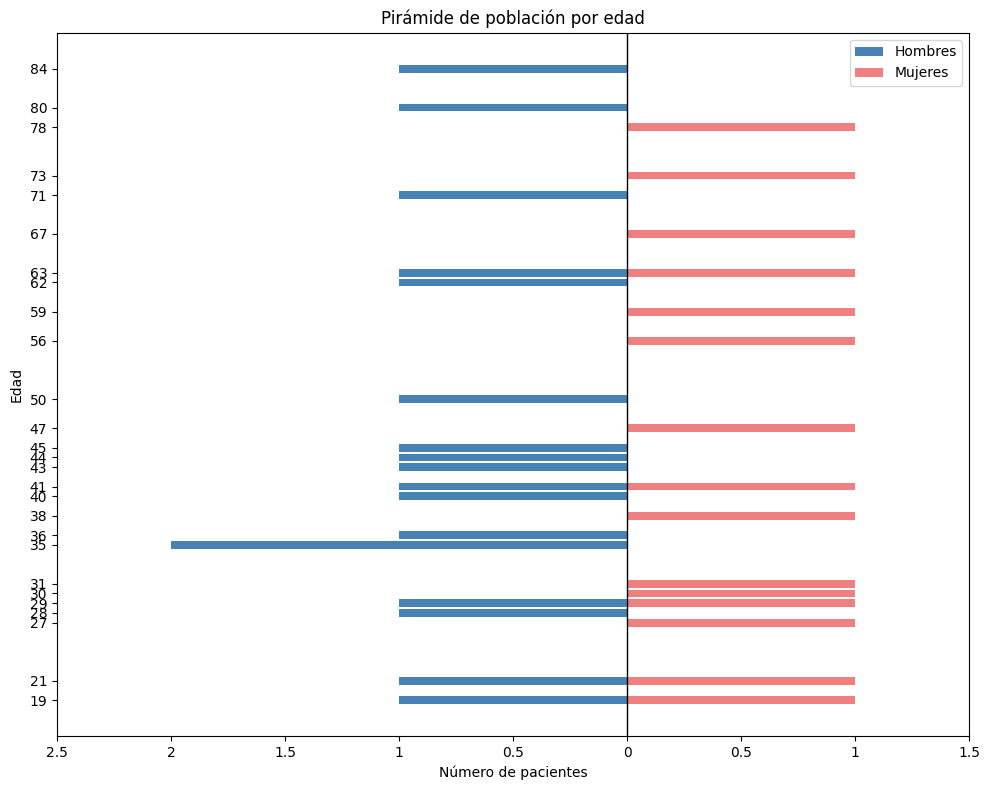

In [4]:
# Pirámide de población por edad y género
piramide = df_pacientes.groupby(["Edad", "Genero"]).size().unstack(fill_value=0)
piramide = piramide.sort_index()

hombres = -piramide.get("Masculino", pd.Series(0, index=piramide.index))
mujeres = piramide.get("Femenino", pd.Series(0, index=piramide.index))

plt.figure(figsize=(10, 8))
plt.barh(piramide.index, hombres, color="steelblue", label="Hombres")
plt.barh(piramide.index, mujeres, color="lightcoral", label="Mujeres")

plt.axvline(0, color="black", linewidth=1)
plt.title("Pirámide de población por edad")
plt.xlabel("Número de pacientes")
plt.ylabel("Edad")
plt.legend()

# Mostrar valores absolutos en el eje X
xticks = plt.xticks()[0]
plt.xticks(xticks, [str(int(abs(x))) if abs(x).is_integer() else f"{abs(x):.1f}" for x in xticks])

# Agregar más ticks en el eje Y
yticks = piramide.index
plt.yticks(yticks, [str(y) for y in yticks])

plt.tight_layout()
plt.show()

# `cohorte_procedimientos.csv`

In [9]:
df_procedimientos_raw = pd.read_csv(os.path.join(DATA_DIR, "cohorte_procedimientos.csv"))
df_procedimientos = df_procedimientos_raw.copy()

In [6]:
df_procedimientos_raw

,PacienteID,Fecha_inicio,Fecha_fin,Codigo_SNOMED,Descripcion
0,6,2024-10-11,2024-10-13,303893007,Resonancia magnética cerebral
1,13,2023-06-09,2023-06-12,241879003,Extracción de muela
2,8,2023-09-08,2023-09-10,80146002,Cirugía de apendicitis
3,4,2023-04-10,2023-04-14,303893007,Resonancia magnética cerebral
4,9,2024-03-26,2024-03-31,80146002,Cirugía de apendicitis
...,...,...,...,...,...
95,10,2024-10-12,2024-10-19,241879003,Extracción de muela
96,2,2024-05-09,2024-05-12,387713003,Electrocardiograma
97,24,2024-05-04,2024-05-06,48387007,Colonoscopía
98,30,2023-10-17,2023-10-19,180325003,Vacunación contra la gripe


In [10]:
conteo_procedimientos = df_procedimientos[['Codigo_SNOMED', 'Descripcion']].value_counts().reset_index(name='count')
conteo_procedimientos

,Codigo_SNOMED,Descripcion,count
0,303893007,Resonancia magnética cerebral,13
1,80146002,Cirugía de apendicitis,11
2,399439001,Cateterismo cardíaco,11
3,233604007,Ecografía abdominal,11
4,241879003,Extracción de muela,11
5,430193006,Sutura de herida,11
6,399208008,Radiografía de tórax,10
7,180325003,Vacunación contra la gripe,9
8,48387007,Colonoscopía,7
9,387713003,Electrocardiograma,6


In [11]:
df_procedimientos["duracion"] = pd.to_datetime(df_procedimientos["Fecha_fin"]) - pd.to_datetime(df_procedimientos["Fecha_inicio"])

In [12]:
df_procedimientos["duracion"].describe()

count                          100
mean               4 days 07:26:24
std      1 days 22:06:27.152186273
min                1 days 00:00:00
25%                3 days 00:00:00
50%                4 days 00:00:00
75%                6 days 00:00:00
max                7 days 00:00:00
Name: duracion, dtype: object

In [14]:
stats_duracion_procedimientos = df_procedimientos.groupby(['Codigo_SNOMED', 'Descripcion'])['duracion'].describe()
stats_duracion_procedimientos

,,count,mean,std,min,25%,50%,75%,max
Codigo_SNOMED,Descripcion,,,,,,,,
48387007,Colonoscopía,7,3 days 10:17:08.571428571,2 days 08:53:27.142732585,1 days 00:00:00,1 days 12:00:00,3 days 00:00:00,5 days 00:00:00,7 days 00:00:00
80146002,Cirugía de apendicitis,11,4 days 08:43:38.181818181,2 days 00:19:34.192443487,1 days 00:00:00,2 days 12:00:00,5 days 00:00:00,6 days 00:00:00,7 days 00:00:00
180325003,Vacunación contra la gripe,9,4 days 13:20:00,2 days 00:09:58.961934609,1 days 00:00:00,4 days 00:00:00,5 days 00:00:00,6 days 00:00:00,7 days 00:00:00
233604007,Ecografía abdominal,11,4 days 10:54:32.727272727,1 days 16:40:40.411710081,1 days 00:00:00,4 days 00:00:00,4 days 00:00:00,5 days 00:00:00,7 days 00:00:00
241879003,Extracción de muela,11,5 days 02:10:54.545454545,1 days 07:12:30.205728662,3 days 00:00:00,4 days 00:00:00,5 days 00:00:00,6 days 00:00:00,7 days 00:00:00
303893007,Resonancia magnética cerebral,13,4 days 11:04:36.923076923,1 days 12:09:12.667752439,2 days 00:00:00,4 days 00:00:00,4 days 00:00:00,5 days 00:00:00,7 days 00:00:00
387713003,Electrocardiograma,6,5 days 00:00:00,2 days 00:00:00,2 days 00:00:00,3 days 18:00:00,6 days 00:00:00,6 days 00:00:00,7 days 00:00:00
399208008,Radiografía de tórax,10,3 days 12:00:00,1 days 22:59:21.697792378,1 days 00:00:00,2 days 06:00:00,3 days 12:00:00,4 days 00:00:00,7 days 00:00:00
399439001,Cateterismo cardíaco,11,4 days 10:54:32.727272727,2 days 08:08:42.958077053,1 days 00:00:00,2 days 00:00:00,5 days 00:00:00,6 days 12:00:00,7 days 00:00:00
